In [1]:
%matplotlib inline
import sys
sys.path.append("/Users/xuegong/Repositories/img_pipe/")
from img_pipe import img_pipe
import matplotlib.pyplot as plt

## Run recon

In [2]:
subj = "BRAVO6"
hem = "lh"

patient = img_pipe.freeCoG(subj = subj, hem = hem, zero_indexed_electrodes=False, add_to_db = False)
# patient.prep_recon()
# patient.check_pial()	

## Creating Mesh

In [4]:
patient.convert_fsmesh2mlab()
patient.convert_fsmesh2mlab(mesh_name = 'inflated')

## create labels
patient.run_annotation2label()
patient.get_subcort()


Making lh mesh
Making rh mesh


## Coregister CT to MRI

In [9]:
patient.reg_img(source='CT.nii',target='orig.mgz')

Computing registration from /Users/xuegong/local_tmp/BRAVO6/CT/CT.nii to /Users/xuegong/local_tmp/BRAVO6/mri/orig.mgz using method nipy
Initial guess...
translation : [0. 0. 0.]
rotation    : [0. 0. 0.]

Optimizing using fmin_powell
translation : [-0.89511474  8.3322657   2.618034  ]
rotation    : [-5.79427303e-05 -3.60223804e-05  1.00000000e-02]

nmi = 0.14085503310155034

translation : [-1.85990844  8.7142317   3.618034  ]
rotation    : [-5.85336999e-05 -3.29458500e-05  7.03806655e-03]

nmi = 0.1419021664042266

Optimization terminated successfully.
         Current function value: -0.141902
         Iterations: 2
         Function evaluations: 85
Saving registered CT image as /Users/xuegong/local_tmp/BRAVO6/CT/rCT.nii


/Users/xuegong/miniconda3/envs/analysis/lib/python3.11/site-packages/nipy/io/files.py:141: FutureWarning: Default `strict` currently False; this will change to True in a future version of nipy
  ni_img = nipy2nifti(img, data_dtype = io_dtype)


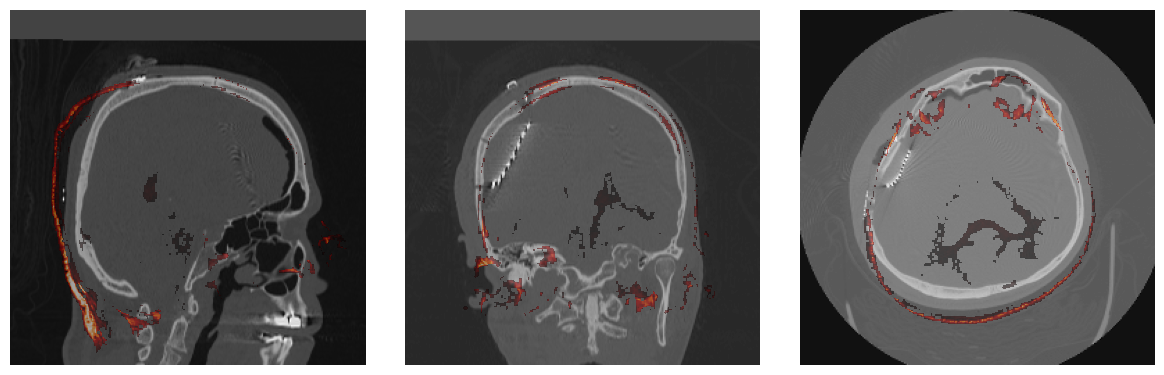

In [14]:
## default method nipy does not work well
patient.plot_overlay()


Computing registration from /Users/xuegong/local_tmp/BRAVO6/CT/CT.nii to /Users/xuegong/local_tmp/BRAVO6/mri/orig.mgz using method ants
Saving registered CT image as /Users/xuegong/local_tmp/BRAVO6/CT/rCT.nii


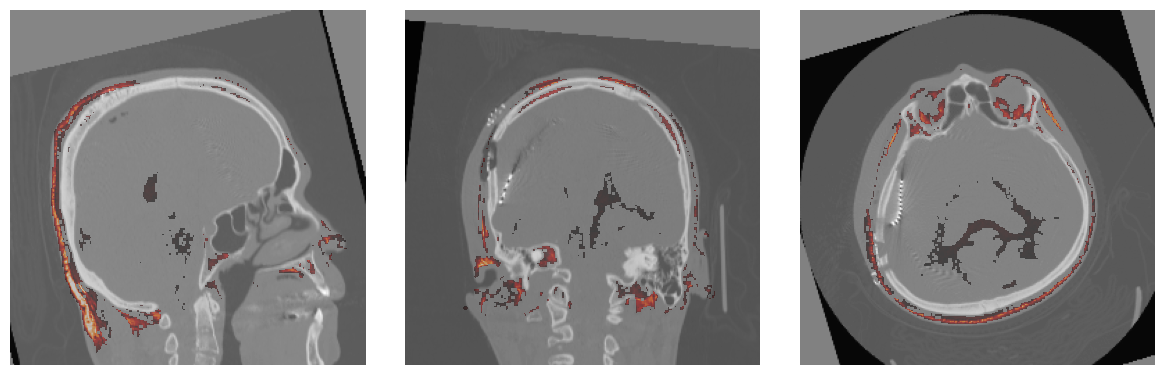

In [15]:
## method ants
patient.reg_img(source='CT.nii',target='orig.mgz', method="ants")
patient.plot_overlay()


## mark electrodes

In [16]:
patient.mark_electrodes()	

Launching electrode picker


2025-03-11 18:47:02.228 python[5891:4223670] +[IMKClient subclass]: chose IMKClient_Legacy
2025-03-11 18:47:02.228 python[5891:4223670] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


3740.236083984375


## Interpolate Grids

In [6]:
patient.interp_grid(nrows = 11, ncols= 23, grid_basename='grid')


In [7]:
elecs = patient.get_elecs(elecfile_prefix='individual_elecs/grid_orig')['elecmatrix']
patient.plot_brain(elecs = elecs, opacity = .3)


2025-03-11 19:13:44.137 python[6440:4249773] +[IMKClient subclass]: chose IMKClient_Legacy
2025-03-11 19:13:44.137 python[6440:4249773] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


(<mayavi.modules.surface.Surface at 0x164fd6e30>,
 <module 'mayavi.mlab' from '/Users/xuegong/miniconda3/envs/analysis/lib/python3.11/site-packages/mayavi/mlab.py'>,
 [],
 <mayavi.core.scene.Scene at 0x161770d10>)

## Project Grids

In [8]:
patient.project_electrodes(elecfile_prefix = 'grid', grid=True, use_mean_normal=True, surf_type='pial', convex_hull=True)


Projection Params: 
	 Grid Name: grid.mat 
	 Use Mean Normal: True 
	                Surface Type: pial 
	 Number of Smoothing Iterations (if using dural): 30
Normal vectors: [array([ 0.84101626, -0.20358213, -0.50124443]), array([ 0.82204458, -0.17899811, -0.54055748]), array([ 0.87909847, -0.1073752 , -0.46438825]), array([ 0.85975084, -0.08363264, -0.50381948])]
Projection direction vector:  [np.float64(-0.8504775365301132), np.float64(0.14339702120092826), np.float64(0.5025024089541316)]
::: Loading Mesh data :::
/Users/xuegong/local_tmp/BRAVO6/Meshes/lh_pial_trivert.mat
::: Projecting electrodes to mesh :::
[np.float64(-0.8504775365301132), np.float64(0.14339702120092826), np.float64(0.5025024089541316)]
::: Done :::
Moving /Users/xuegong/local_tmp/BRAVO6/elecs/individual_elecs/grid_orig.mat to /Users/xuegong/local_tmp/BRAVO6/elecs/individual_elecs/preproc


In [7]:
elecs = patient.get_elecs(elecfile_prefix='individual_elecs/grid')['elecmatrix']
patient.plot_brain(elecs = elecs, opacity = .3)


(<mayavi.modules.surface.Surface at 0x163abede0>,
 <module 'mayavi.mlab' from '/Users/xuegong/miniconda3/envs/analysis/lib/python3.11/site-packages/mayavi/mlab.py'>,
 [],
 <mayavi.core.scene.Scene at 0x163ad1580>)

## Make Elecs_all files

In [3]:
patient.make_elecs_all(outfile="grid")


Are you adding a row that will be NaN in the elecmatrix? If not, press enter. If so, enter the number of empty rows to add: 
 
What is the short name prefix of the device (e.g. G, AD, HD)?
 grid
What is the long name prefix of the device? (e.g. L256Grid, HippocampalDepth)
 grid
What is the type of the device? (e.g. grid, strip, depth)
 grid
What is the filename of the device's electrode coordinate matrix?
 grid
Finished entering devices? Enter 'y' if finished. y
What filename would you like to save out to?
 grid


In [9]:
## add anatomy label
patient.label_elecs(elecfile_prefix='grid')

/Users/xuegong/local_tmp
Creating labels from the freesurfer annotation file for use in automated electrode labeling
subject = BRAVO6
annotation = aparc
hemi = lh
outdir = /Users/xuegong/local_tmp/BRAVO6/label/gyri
surface   = pial

Reading surface 
 /Users/xuegong/local_tmp/BRAVO6/surf/lh.pial
Loading annotations from /Users/xuegong/local_tmp/BRAVO6/label/lh.aparc.annot
Seg base 1000
max index = 35
  0      0  empty --- skipping 
  1   1515 /Users/xuegong/local_tmp/BRAVO6/label/gyri/lh.bankssts.label
  2    915 /Users/xuegong/local_tmp/BRAVO6/label/gyri/lh.caudalanteriorcingulate.label
  3   2941 /Users/xuegong/local_tmp/BRAVO6/label/gyri/lh.caudalmiddlefrontal.label
  4      0  empty --- skipping 
  5   2201 /Users/xuegong/local_tmp/BRAVO6/label/gyri/lh.cuneus.label
  6    762 /Users/xuegong/local_tmp/BRAVO6/label/gyri/lh.entorhinal.label
  7   4210 /Users/xuegong/local_tmp/BRAVO6/label/gyri/lh.fusiform.label
  8   8697 /Users/xuegong/local_tmp/BRAVO6/label/gyri/lh.inferiorparietal.l

array([[np.str_('grid1'), np.str_('grid1'), np.str_('grid'),
        'middletemporal'],
       [np.str_('grid2'), np.str_('grid2'), np.str_('grid'),
        'middletemporal'],
       [np.str_('grid3'), np.str_('grid3'), np.str_('grid'),
        'middletemporal'],
       ...,
       [np.str_('grid251'), np.str_('grid251'), np.str_('grid'),
        'precentral'],
       [np.str_('grid252'), np.str_('grid252'), np.str_('grid'),
        'caudalmiddlefrontal'],
       [np.str_('grid253'), np.str_('grid253'), np.str_('grid'),
        'caudalmiddlefrontal']], dtype=object)

In [3]:
## visualize for sanity check
patient.plot_recon_anatomy(elecfile_prefix='grid', opacity = 0.6)

ctx-lh-caudalmiddlefrontal
ctx-lh-middletemporal
ctx-lh-parsopercularis
ctx-lh-postcentral
ctx-lh-precentral
ctx-lh-superiortemporal
ctx-lh-supramarginal


2025-03-11 19:25:12.538 python[6618:4262568] +[IMKClient subclass]: chose IMKClient_Legacy
2025-03-11 19:25:58.971 python[6618:4262568] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


(<mayavi.modules.surface.Surface at 0x1630469d0>,
 <module 'mayavi.mlab' from '/Users/xuegong/miniconda3/envs/analysis/lib/python3.11/site-packages/mayavi/mlab.py'>)